In [ ]:
!pip install -q transformers pyvi torch sklearn matplotlib pandas peft
!pip install --upgrade torchao

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 83.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
# Re-install pyvi and underthesea to ensure Vietnamese text processing libraries are available
!pip install -q pyvi underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 139.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.5 MB/s eta 0:00:00


In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from pyvi import ViTokenizer
from sklearn.metrics import f1_score, classification_report

In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Tạo thư mục lưu trữ mô hình nếu chưa có
SAVE_PATH = '/content/drive/MyDrive/ABSA_Task2'
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)
    print(f"Da tao thu muc: {SAVE_PATH}")
else:
    print(f"Thu muc lưu tru: {SAVE_PATH}")

Mounted at /content/drive
Thu muc lưu tru: /content/drive/MyDrive/ABSA_Task2


In [ ]:
# Giai nen file dataset tu MyDrive vao /content
ZIP_FILE = '/content/drive/MyDrive/task2_dataset.zip'
!unzip -q {ZIP_FILE} -d /content/

# Kiem tra cac file sau khi giai nen
DATA_DIR = '/content/task2_dataset'
files = os.listdir(DATA_DIR)
print(f"Cac file trong {DATA_DIR}: {files}")

Cac file trong /content/task2_dataset: ['1-VLSP2018-SA-Hotel-train.csv', '2-VLSP2018-SA-Hotel-dev.csv', '3-VLSP2018-SA-Hotel-test.csv']


In [ ]:
# Tham so cau hinh
MAX_LEN = 256
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 2e-5
MODEL_NAME = "vinai/phobert-base"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Danh sach 34 Aspect Categories theo VLSP 2018
ASPECT_COLS = [
    "FACILITIES#CLEANLINESS", "FACILITIES#COMFORT", "FACILITIES#DESIGN&FEATURES", "FACILITIES#GENERAL",
    "FACILITIES#MISCELLANEOUS", "FACILITIES#PRICES", "FACILITIES#QUALITY", "FOOD&DRINKS#MISCELLANEOUS",
    "FOOD&DRINKS#PRICES", "FOOD&DRINKS#QUALITY", "FOOD&DRINKS#STYLE&OPTIONS", "HOTEL#CLEANLINESS",
    "HOTEL#COMFORT", "HOTEL#DESIGN&FEATURES", "HOTEL#GENERAL", "HOTEL#MISCELLANEOUS", "HOTEL#PRICES",
    "HOTEL#QUALITY", "LOCATION#GENERAL", "ROOMS#CLEANLINESS", "ROOMS#COMFORT", "ROOMS#DESIGN&FEATURES",
    "ROOMS#GENERAL", "ROOMS#MISCELLANEOUS", "ROOMS#PRICES", "ROOMS#QUALITY", "ROOM_AMENITIES#CLEANLINESS",
    "ROOM_AMENITIES#COMFORT", "ROOM_AMENITIES#DESIGN&FEATURES", "ROOM_AMENITIES#GENERAL",
    "ROOM_AMENITIES#MISCELLANEOUS", "ROOM_AMENITIES#PRICES", "ROOM_AMENITIES#QUALITY", "SERVICE#GENERAL"
]

In [ ]:
class ABSADataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.texts = df['Review'].values
        self.labels = df[ASPECT_COLS].values

    def __len__(self):
        return len(self.df)

    def preprocess(self, text):
        # Tach tu tieng Viet cho PhoBERT
        return ViTokenizer.tokenize(str(text).lower())

    def __getitem__(self, index):
        text = self.preprocess(self.texts[index])
        labels = self.labels[index]

        encoding = self.tokenizer(
            text,
            truncation=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(labels, dtype=torch.long)
        }

# Khoi tao Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load data
train_df = pd.read_csv(f"{DATA_DIR}/1-VLSP2018-SA-Hotel-train.csv")
dev_df = pd.read_csv(f"{DATA_DIR}/2-VLSP2018-SA-Hotel-dev.csv")
test_df = pd.read_csv(f"{DATA_DIR}/3-VLSP2018-SA-Hotel-test.csv")

# Khoi tao DataLoaders
train_ds = ABSADataset(train_df, tokenizer, MAX_LEN)
dev_ds = ABSADataset(dev_df, tokenizer, MAX_LEN)
test_ds = ABSADataset(test_df, tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from peft import LoraConfig, get_peft_model

class PhoBertACSA_LoRA(nn.Module):
    def __init__(self, n_aspects, n_polarities):
        super(PhoBertACSA_LoRA, self).__init__()

        phobert = AutoModel.from_pretrained(MODEL_NAME)

        # Cau hinh LoRA
        lora_config = LoraConfig(
            r=8,
            lora_alpha=16,
            target_modules=["query", "value"], # Ap dung LoRA vao cac khoi Attention
            lora_dropout=0.1,
            bias="none"
        )

        # Dong bang backbone va chi mo r cho cac module LoRA
        self.phobert = get_peft_model(phobert, lora_config)

        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, n_aspects * n_polarities)
        self.n_aspects = n_aspects
        self.n_polarities = n_polarities

    def forward(self, input_ids, attention_mask):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :] # Lay CLS token
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits.view(-1, self.n_aspects, self.n_polarities)

model = PhoBertACSA_LoRA(n_aspects=len(ASPECT_COLS), n_polarities=4).to(DEVICE)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Cấu hình trọng số: ép mô hình chú ý vào Negative (2) và Neutral (3) nhiều hơn
# Thứ tự nhãn: [None, Positive, Negative, Neutral]
class_weights = torch.tensor([0.1, 1.0, 2.0, 3.0]).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
# Chỉ đưa các tham số có requires_grad=True (bao gồm LoRA adapter và Linear Classifier) vào AdamW
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params, lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)

        # Loss tinh tong ca 34 aspects
        loss = criterion(outputs.view(-1, 4), labels.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in dev_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs.view(-1, 4), labels.view(-1))
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(dev_loader)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), f"{SAVE_PATH}/best_model_sft.bin")
        print("--- Da luu model tot nhat ---")

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch 1/10 | Train Loss: 1.2802 | Val Loss: 1.1811
--- Da luu model tot nhat ---
Epoch 2/10 | Train Loss: 1.1197 | Val Loss: 1.0813
--- Da luu model tot nhat ---
Epoch 3/10 | Train Loss: 1.0634 | Val Loss: 1.0469
--- Da luu model tot nhat ---
Epoch 4/10 | Train Loss: 1.0406 | Val Loss: 1.0310
--- Da luu model tot nhat ---
Epoch 5/10 | Train Loss: 1.0281 | Val Loss: 1.0199
--- Da luu model tot nhat ---
Epoch 6/10 | Train Loss: 1.0161 | Val Loss: 1.0096
--- Da luu model tot nhat ---
Epoch 7/10 | Train Loss: 1.0062 | Val Loss: 1.0001
--- Da luu model tot nhat ---
Epoch 8/10 | Train Loss: 0.9926 | Val Loss: 0.9928
--- Da luu model tot nhat ---
Epoch 9/10 | Train Loss: 0.9840 | Val Loss: 0.9880
--- Da luu model tot nhat ---
Epoch 10/10 | Train Loss: 0.9804 | Val Loss: 0.9866
--- Da luu model tot nhat ---


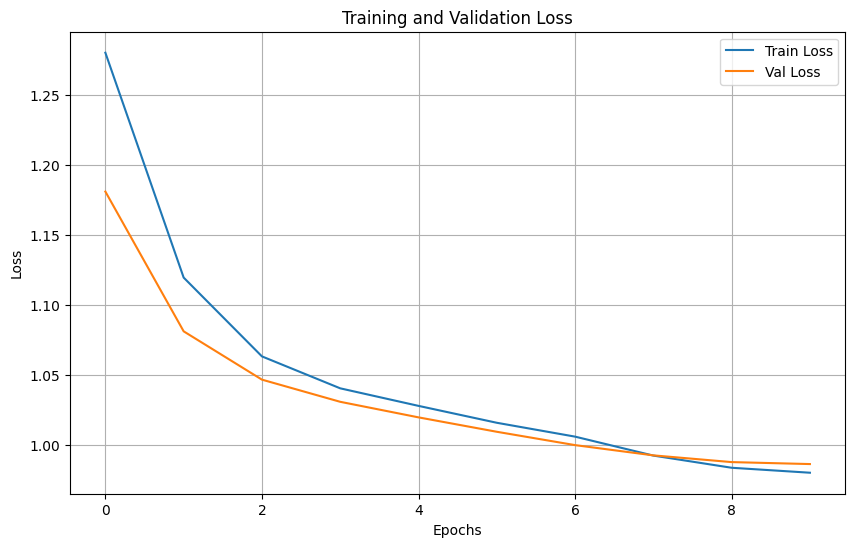

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Khởi tạo kiến trúc LoRA trước khi nạp trọng số (weights)
model = PhoBertACSA_LoRA(n_aspects=len(ASPECT_COLS), n_polarities=4).to(DEVICE)
model.load_state_dict(torch.load(f"{SAVE_PATH}/best_model_sft.bin"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].cpu().numpy()

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=2).cpu().numpy()

        y_true.extend(labels)
        y_pred.extend(preds)

y_true = np.array(y_true).reshape(-1)
y_pred = np.array(y_pred).reshape(-1)

print("Ket qua chi tiet tren tap Test (tat ca khia canh gop chung):")
print(classification_report(y_true, y_pred, target_names=["None", "Positive", "Negative", "Neutral"]))

# Tính F1-macro cho mục tiêu chính
final_f1 = f1_score(y_true, y_pred, average='macro')
print(f"\nF1-macro tong the: {final_f1:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ket qua chi tiet tren tap Test (tat ca khia canh gop chung):
              precision    recall  f1-score   support

        None       0.96      0.64      0.77     17816
    Positive       0.21      0.76      0.33      1806
    Negative       0.14      0.44      0.21       645
     Neutral       0.00      0.00      0.00       133

    accuracy                           0.64     20400
   macro avg       0.33      0.46      0.33     20400
weighted avg       0.86      0.64      0.71     20400


F1-macro tong the: 0.3280


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
